<a href="https://colab.research.google.com/github/MariaBessa1/SeriedeTaylor_TangenteHiperbolica/blob/main/EP_1_Computa%C3%A7%C3%A3o_Cientifica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Funções Hiperbólicas - Tangente Hiperbólica e Série de Taylor
###Grupo: Maria Clara Fernandes Bessa, João Vitor Tavares e Nycolly Vitória de Oliveira




Uma Função Hiperbólica, também conhecida comon Função Trigonométrica Hiperbólica assemelha-se, como esperado, a uma função trigonométrica comum. A diferença principal se dá pela sua aplicação ocorrer em uma Hipérbole, não em um círculo.

Enquanto Cos(θ) e Sen(θ) são obtidos através de um ponto P(X,Y) -> P(Cos(θ), Sen(θ)) definido em uma **circunferência** onde a equação equivale à x(ˆ2 + Yˆ2 = 1) e indica o ângulo que forma um determinado espaço, Cosh(x) e Senh(x), por exemplo, trabalham somente com a área (sem o ângulo) e podem ser obtidos através de um ponto determinado no decorrer da **hipérbole**.

Nesta atividade, estudaremos o comportamento da Tangente Hiperbólica em uma Série de Taylor, compreendendo suas propriedades e aplicações enquanto tornamos possível a análise computacional através da linguagem Python. Diversas contas e elaborações de pensamentos lógicos ocorreram por meio de anotações físicas em papel, as quais foram passadas para o digital por meio da ferramenta "FIgJam", oriunda do Figma. A seguir disponibilizaremos o link para que o registro possa ser consultado:

https://www.figma.com/board/jZ9tSPWBesQiTSZkNA2TmS/EP---Tangente-Hiperb%C3%B3lica?node-id=0-1&t=yzAQeFYGrCXPQG12-1


##Cálculo das derivadas

Como início, definimos as derivadas da função para podermos entender quais seriam utilizadas e quais termos seriam removidos da série. Por requerir cálculos e uma construção lógica tomada por nós durante os cálculos manuais, esta etapa foi inserida no FigJam, podendo ser visualizada por lá.


##Valores de x que a Série de Taylor converge para a função original Tangh(x)

###Série de Taylor expandida (primeiros termos):

A série de Taylor da Tangente Hiperbólica, considerando o centro (a) como 0, ou seja, o ponto fixo em torno do qual a função é aproximada, converge para a função original enquanto x estiver contido do intervalo $$ \left( -\frac{\pi}{2}, \frac{\pi}{2} \right) $$

(aproximadamente 1,57). Tendo esses valores como referenciais, trabalharemos com x dentro do intervalo de -1,57 até 1,57, sendo eles **[-1,5, -1, - 0,5, 0, 0,5, 1 e 1,5]** e aplicando  série de fato somente à **[0, 0,5, 1 e 1,5]**, pois o resultado dos demais será o mesmo com a adição do sinal negativo


---


Por estarmos considerando 0 como o centro, podemos chegar a algumas conclusões prévias: O valor da série de Taylor em x = 0 será exatamente o mesmo da função **Tanh(x)**, isso por que o termo (a - x) da série se tornará (a - a). Eliminando-o, restará somente f(a) e suas derivadas, evidenciando que, no centro, a série devolve o próprio número que colocado nela.

##Escolha do valor de N

Quanto mais longe o valor de x do centro, maior deve ser o valor de N para que haja uma precisão vantajosa da série em relação função original. Entrenato, por 1,57 ser aproximadamente o valor máximo de x que a série converge para a função, é de se imaginar que necessitará de um alto valor de N. O valor do erro demorará a cair e haverá uma alta quantidade necessária de contas, não compensando então incluir um limite de N que englobe essa aproximação exata.

Para a análise inicial, foi considerado o valor de N = 40.


## Fórmulas para maior noção das aplicações (Centro = 0)

**Fórmula padrão de Taylor** (centro $a$):

$$
f(x) = f(a) + f'(a)(x-a) + \frac{f''(a)}{2!}(x-a)^2 + \frac{f'''(a)}{3!}(x-a)^3 + \cdots
= \sum_{k=0}^{\infty} \frac{f^{(k)}(a)}{k!}\,(x-a)^k
$$

**Com centro $a = 0$**, o termo $(x-a)$ vira $x$:

$$
f(x) = f(0) + f'(0)\,x + \frac{f''(0)}{2!}\,x^2 + \frac{f'''(0)}{3!}\,x^3 + \cdots
= \sum_{k=0}^{\infty} \frac{f^{(k)}(0)}{k!}\,x^k
$$

**Aplicada à tangente hiperbólica** (f(x) = tanh(x):)

Como $\tanh(0)=0$ e as derivadas de ordem par também valem $0$ em $x=0$, só sobram os expoentes ímpares $k = 2n+1$:

$$
\tanh(x) = \sum_{n=0}^{\infty} \frac{f^{(2n+1)}(0)}{(2n+1)!}\,x^{2n+1}
= x - \frac{x^3}{3} + \frac{2x^5}{15} - \frac{17x^7}{315} + \cdots
$$


---



In [ ]:
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fractions import Fraction

##Cálculo da Série de Taylor

In [ ]:
def tanh_taylor(x, n):

    P = [0, 1] # valor que vai acompanhar os y nas derivadas. Começa com 0 e 1 por que a função, sem derivar, é y = tangh(x) ou y = 1y. 0 coeficiente, 1 acompanhando o y
    coefs = [] #guarda os coeficientes finais da serie
    for k in range(2 * n):
        if k % 2 == 1: #se o coeficiente for impar, ele permanece e dividido pelo fatorial
            coefs.append(P[0] / math.factorial(k)) # resultado da derivada / fatorial

# cálculo das derivadas (regra da cadeia)
        dP = [j * P[j] for j in range(1, len(P))]
        novo = [0] * (len(dP) + 2)
        for j, c in enumerate(dP):
            novo[j] += c
            novo[j + 2] -= c
        P = novo

# soma da série
    soma = 0.0
    for i in range(n):
        soma += coefs[i] * x ** (2 * i + 1)
    return soma

In [ ]:
tanh_taylor(0.5,30)

0.4621171572600097

Apesar deste algoritmo possuir a lógica elaborada manualmente das derivadas, ele não está otimizado. Pode funcionar para números pequenos de N, porém, como já apresentado anteriormente, a série pode precisar de um grande valor de N a depender da distância de um valor de x do definido como "centro".

##Cálculo da Série de Taylor Otimizada

In [ ]:
def tanh_taylor_otimizado(x, n):
    x = np.asarray(x, dtype=float)

    P = [0, 1]
    coefs = []
    for k in range(2 * n):
        if k % 2 == 1:
            coefs.append(P[0] / math.factorial(k))
        dP = [j * P[j] for j in range(1, len(P))]
        novo = [0] * (len(dP) + 2)
        for j, c in enumerate(dP):
            novo[j] += c
            novo[j + 2] -= c
        P = novo

    x2 = x ** 2 #os expoentes nao sao calculados mais com 2i+1

# método de horner: AO inves de calcular termo por termo com suas respectivas potencias e inúmeras multiplicações, vai calcular de forma mais simples e otimizada (presente no figJam)
    soma = np.full_like(x2, coefs[-1])
    for c in reversed(coefs[:-1]):
        soma = soma * x2 + c

    return x * soma

In [ ]:
tanh_taylor_otimizado(0.5,30)

np.float64(0.4621171572600098)

##Tabelas de Valores Fixos

In [ ]:
pontos_fixos = np.array([0.0, 0.5, 1.0, 1.5])
y_exato = np.tanh(pontos_fixos)

tabela_dados = {'x': pontos_fixos, 'tanh(x) Exato': y_exato}

# Avaliação com diferentes números de termos (N = 1, 3, 5, 10)
for n in [1, 20, 30, 40]:
    y_approx = tanh_taylor(pontos_fixos, n)
    tabela_dados[f'Taylor (N={n})'] = y_approx
    tabela_dados[f'Erro Abs (N={n})'] = np.abs(y_exato - y_approx)

df_tabela = pd.DataFrame(tabela_dados)

display(df_tabela)

,x,tanh(x) Exato,Taylor (N=1),Erro Abs (N=1),Taylor (N=20),Erro Abs (N=20),Taylor (N=30),Erro Abs (N=30),Taylor (N=40),Erro Abs (N=40)
0,0.0,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00
1,0.5,0.462117,0.5,0.037883,0.462117,5.551115e-17,0.462117,5.551115e-17,0.462117,5.551115e-17
2,1.0,0.761594,1.0,0.238406,0.761594,8.245763e-09,0.761594,9.859891e-13,0.761594,2.220446e-16
3,1.5,0.905148,1.5,0.594852,0.804623,1.005249e-01,0.865181,3.996698e-02,0.889258,1.589019e-02


Pode-se observar que, quanto mais próximo do valor 0 em X, menor a quantidade de termos **(N)** necessária para que a convergência com a função original ocorra. Mesmo com 40 termos, ainda não foi o suficiente para que uma aproximação perfeita de x = 1,5 ocorresse, estando a Série de Taylor ainda distante do resultado original ofertado pela função **tanh(x)**.

Ademais, percebe-se que em N = 1, o valor é exatamente o de x. Isso acontece pois, na Série de Taylor da Tangente Hiperbólica, o primeiro termo é composto somente por x.

##Erros da função vs Tempo de execução

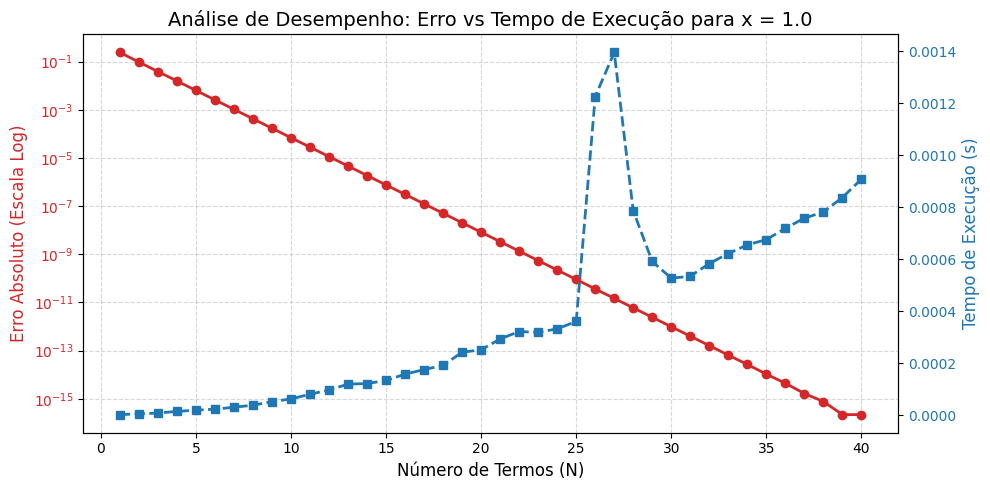

In [ ]:
x_teste = 1.0
y_real = np.tanh(x_teste)

termos_n = list(range(1, 41))
erros_absolutos = []
tempos_execucao = []

for n in termos_n:
    inicio = time.perf_counter()
    for _ in range(1000):
        y_pred = tanh_taylor(x_teste, n)
    fim = time.perf_counter()

    tempo_medio = (fim - inicio) / 1000.0
    erro = np.abs(y_real - y_pred)

    erros_absolutos.append(erro)
    tempos_execucao.append(tempo_medio)

fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Número de Termos (N)', fontsize=12)
ax1.set_ylabel('Erro Absoluto (Escala Log)', color=color, fontsize=12)
ax1.semilogy(termos_n, erros_absolutos, color=color, marker='o', linewidth=2, label='Erro Absoluto')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, which="both", ls="--", alpha=0.5)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Tempo de Execução (s)', color=color, fontsize=12)
ax2.plot(termos_n, tempos_execucao, color=color, marker='s', linestyle='--', linewidth=2, label='Tempo (s)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title(f'Análise de Desempenho: Erro vs Tempo de Execução para x = {x_teste}', fontsize=14)
fig.tight_layout()
plt.show()

Demonstração física do que já vem sendo discutido. Ao passo que o número de termos aumenta, seu erro diminui (o que significa que a série está convergindo para a função original). Entretanto, a existência de um maior número de termos também requer um maior nível de cálculos, o que aumenta o tempo de execução.